In [1]:
#Step 1: Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

#import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [2]:
#Step 2: Load Dataset
df = pd.read_csv("1_boston_housing.csv")

print(df.head())

      CRIM    ZN  INDUS  CHAS    NOX     RM   AGE     DIS  RAD  TAX  PTRATIO  \
0  0.00632  18.0   2.31     0  0.538  6.575  65.2  4.0900    1  296     15.3   
1  0.02731   0.0   7.07     0  0.469  6.421  78.9  4.9671    2  242     17.8   
2  0.02729   0.0   7.07     0  0.469  7.185  61.1  4.9671    2  242     17.8   
3  0.03237   0.0   2.18     0  0.458  6.998  45.8  6.0622    3  222     18.7   
4  0.06905   0.0   2.18     0  0.458  7.147  54.2  6.0622    3  222     18.7   

        B  LSTAT  MEDV  
0  396.90   4.98  24.0  
1  396.90   9.14  21.6  
2  392.83   4.03  34.7  
3  394.63   2.94  33.4  
4  396.90   5.33  36.2  


In [3]:
# Step 3: Split Features and Target
X = df.drop("MEDV", axis=1)   # Features (13)
y = df["MEDV"]                # Target

print(X.shape, y.shape)

(506, 13) (506,)


In [4]:
# Step 4: Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [5]:
# Step 5: Feature Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [6]:
# Step 6: Build (Linear) Neural Network
model = Sequential()
model.add(Dense(1, input_shape=(X_train.shape[1],), activation='linear'))

model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

model.summary()

C:\Users\rawat\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape          ┃      Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━┩
│ dense (Dense)                 │ (None, 1)             │           14 │
└───────────────────────────────┴───────────────────────┴──────────────┘

 Total params: 14 (56.00 B)

 Trainable params: 14 (56.00 B)

 Non-trainable params: 0 (0.00 B)

In [7]:
# Step 7: Train Model
history = model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=16,
    validation_split=0.2,
    verbose=1
)

Epoch 1/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 3s 39ms/step - loss: 609.2476 - mae: 22.9518 - val_loss: 552.7387 - val_mae: 22.1129
Epoch 2/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 607.0345 - mae: 22.9322 - val_loss: 551.1645 - val_mae: 22.0970
Epoch 3/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 605.0466 - mae: 22.9123 - val_loss: 549.6970 - val_mae: 22.0805
Epoch 4/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 602.9612 - mae: 22.8870 - val_loss: 548.2915 - val_mae: 22.0631
Epoch 5/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 601.1329 - mae: 22.8684 - val_loss: 546.8452 - val_mae: 22.0468
Epoch 6/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 599.0820 - mae: 22.8446 - val_loss: 545.4753 - val_mae: 22.0301
Epoch 7/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 597.2589 - mae: 22.8249 - val_loss: 544.0878 - val_mae: 22.0138
Epoch 8/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 595.3918 - mae: 22.8016 - val_loss: 542.8221 - val_mae: 21.9966
Epoch 9/

In [8]:
# Step 8: Evaluate Model
loss, mae = model.evaluate(X_test, y_test, verbose=0)
print("Test Loss (MSE):", loss)
print("Test MAE:", mae)

Test Loss (MSE): 445.1338806152344
Test MAE: 20.268651962280273


In [9]:
# Step 9: Predictions
y_pred = model.predict(X_test)

# Compare actual vs predicted (first 5 samples)
for i in range(5):
    print(f"Actual: {y_test.iloc[i]:.2f} | Predicted: {y_pred[i][0]:.2f}")

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
Actual: 23.60 | Predicted: 4.72
Actual: 32.40 | Predicted: 10.27
Actual: 13.60 | Predicted: -4.28
Actual: 22.80 | Predicted: 4.54
Actual: 16.10 | Predicted: -2.50


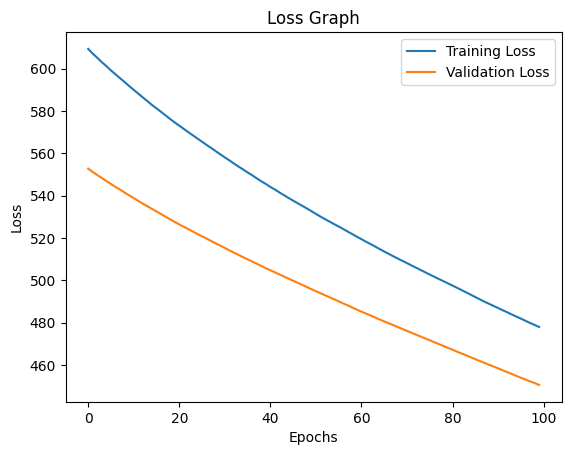

In [10]:
# Step 10: Plot Training Graphs
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title("Loss Graph")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.show()